Centroid: lon=15.8980  lat=-18.9454
Saved → etosha_ndvi_map.png

1 km grid : (159, 337)
5 km grid : (31, 67)
Cells inside park (5 km, centre-point rule): 910
Saved → fire_risk_5km.csv


/tmp/ipykernel_14980/1011039598.py:169: RuntimeWarning: Mean of empty slice
  block_sum  = np.nanmean(reshaped, axis=(1, 3)) #* block * block


Saved → etosha_ndvi_5km.png


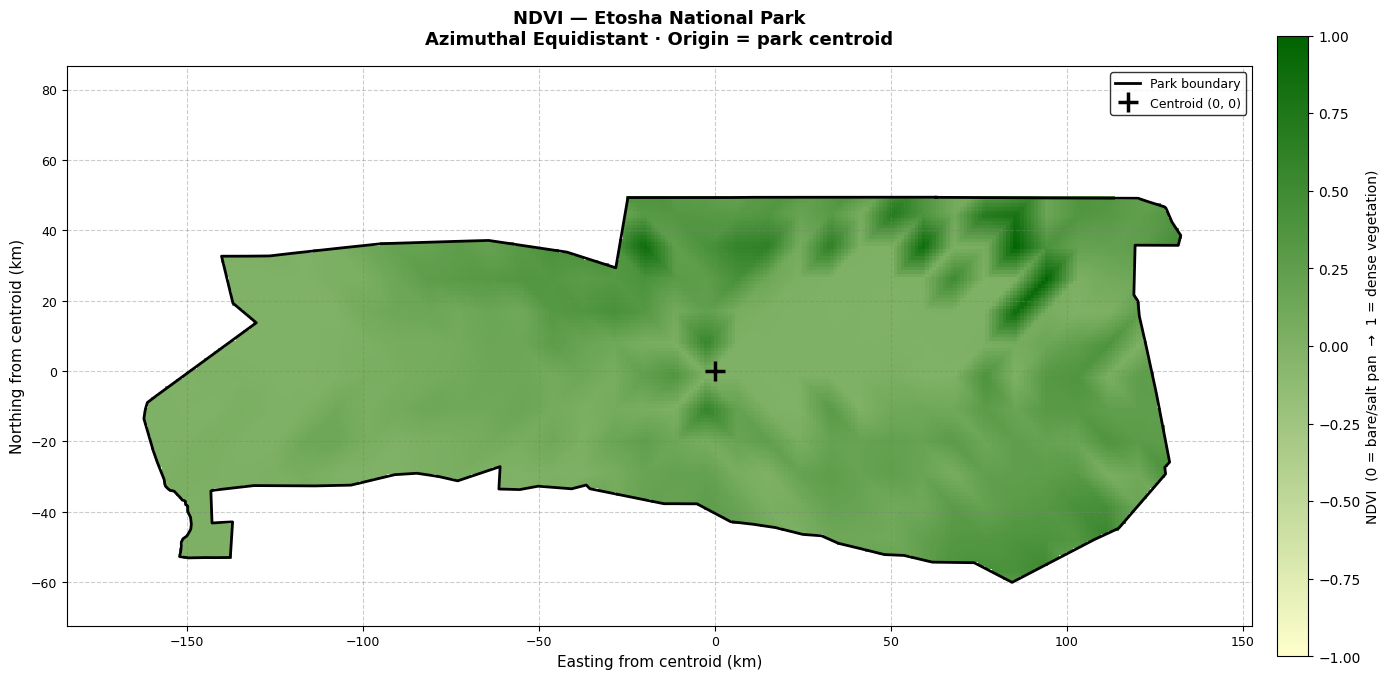

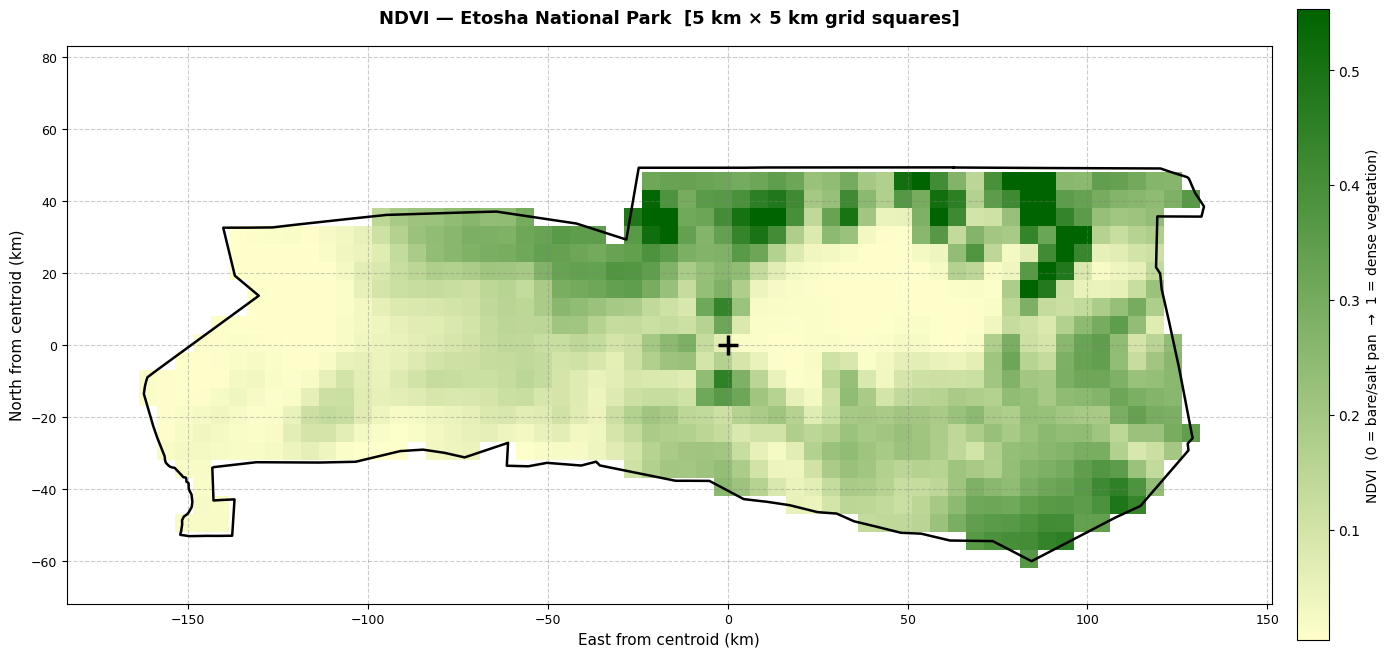

In [13]:
"""
NDVI Visualization — Etosha National Park
==========================================
Reads matrix CSV + shapefile, reprojects to metre-based AEQD coords
centred on the park, interpolates NDVI onto a regular grid, and plots.
 
Dependencies:
    pip install pandas numpy matplotlib pyproj geopandas fiona shapely scipy
"""
 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import shapely
from pyproj import Transformer
from scipy.interpolate import griddata
 
# ── Config ────────────────────────────────────────────────────────────────────
CSV_PATH   = "ndvi.csv"
SHP_PATH   = "WDPA_WDOECM_Apr2026_Public_884_shp-polygons.shp"
OUTPUT_PNG = "etosha_ndvi_map.png"
NDVI_SCALE = 1000.0   # raw values are NDVI × 1000
GRID_RES   = 1        # 1 km interpolation grid (we aggregate to 5 km after)
# ─────────────────────────────────────────────────────────────────────────────
 
 
# ── 1. Load CSV → long format ─────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH, header=0, index_col=0)
df_raw.index   = df_raw.index.astype(float)
df_raw.columns = df_raw.columns.astype(float)
 
records = []
for lat in df_raw.index:
    for lon in df_raw.columns:
        records.append({
            "lat":  lat,
            "lon":  lon,
            "ndvi": df_raw.loc[lat, lon] / NDVI_SCALE,
        })
df = pd.DataFrame(records)
 
 
# ── 2. Load shapefile ─────────────────────────────────────────────────────────
os.environ["SHAPE_RESTORE_SHX"] = "YES"
park = gpd.read_file(SHP_PATH)
park = park.set_crs("EPSG:4326") if park.crs is None else park.to_crs("EPSG:4326")
 
 
# ── 3. AEQD projection centred on park centroid ───────────────────────────────
centroid = park.geometry.union_all().centroid
center_lon, center_lat = centroid.x, centroid.y
print(f"Centroid: lon={center_lon:.4f}  lat={center_lat:.4f}")
 
proj_str = (
    f"+proj=aeqd +lat_0={center_lat} +lon_0={center_lon} "
    "+datum=WGS84 +units=m +no_defs"
)
transformer = Transformer.from_crs("EPSG:4326", proj_str, always_xy=True)
 
 
# ── 4. Reproject NDVI points → km ────────────────────────────────────────────
x_m, y_m    = transformer.transform(df["lon"].values, df["lat"].values)
df["x_km"]  = x_m / 1000
df["y_km"]  = y_m / 1000
 
 
# ── 5. Reproject park polygon ─────────────────────────────────────────────────
park_proj  = park.to_crs(proj_str)
park_union = park_proj.geometry.union_all()
 
 
# ── 6. Interpolate onto 1 km grid ─────────────────────────────────────────────
xi = np.arange(df.x_km.min() - 5, df.x_km.max() + 5, GRID_RES)
yi = np.arange(df.y_km.min() - 5, df.y_km.max() + 5, GRID_RES)
XI, YI = np.meshgrid(xi, yi)
ZI = griddata((df.x_km, df.y_km), df.ndvi, (XI, YI), method="linear")
 
 
# ── 7. Park mask at 1 km ──────────────────────────────────────────────────────
inside_mask_1km = shapely.contains_xy(
    park_union,
    (XI * 1000).ravel(),
    (YI * 1000).ravel(),
).reshape(XI.shape)
 
ZI[~inside_mask_1km] = np.nan
 
 
# ── 8. Plot 1 km map ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
ax.set_facecolor("white")
 
cmap = mcolors.LinearSegmentedColormap.from_list("ndvi", ["#ffffcc", "#006400"])
cmap.set_bad(color="white")
norm = mcolors.Normalize(vmin=-1, vmax=1)
 
ax.pcolormesh(XI, YI, ZI, cmap=cmap, norm=norm, shading="auto", zorder=1)
 
# Park boundary
for geom in park_proj.geometry:
    if geom.geom_type == "Polygon":
        xs, ys = geom.exterior.xy
        ax.plot([x / 1000 for x in xs], [y / 1000 for y in ys],
                color="black", linewidth=2.0, zorder=4, label="Park boundary")
    elif geom.geom_type == "MultiPolygon":
        for part in geom.geoms:
            xs, ys = part.exterior.xy
            ax.plot([x / 1000 for x in xs], [y / 1000 for y in ys],
                    color="black", linewidth=2.0, zorder=4, label="Park boundary")
 
ax.plot(0, 0, "+", color="black", markersize=14,
        markeredgewidth=2.5, zorder=6, label="Centroid (0, 0)")
 
ax.grid(True, linestyle="--", alpha=0.4, color="gray", zorder=0)
ax.set_xlabel("Easting from centroid (km)",  fontsize=11, color="black")
ax.set_ylabel("Northing from centroid (km)", fontsize=11, color="black")
ax.tick_params(colors="black", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("black")
 
ax.set_title(
    "NDVI — Etosha National Park\n"
    "Azimuthal Equidistant · Origin = park centroid",
    fontsize=13, fontweight="bold", color="black", pad=16,
)
 
sm   = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.025)
cbar.set_label("NDVI  (0 = bare/salt pan  →  1 = dense vegetation)",
               fontsize=10, color="black")
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="black")
 
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), loc="upper right", fontsize=9,
          facecolor="white", edgecolor="black", labelcolor="black")
 
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=160, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print(f"Saved → {OUTPUT_PNG}")
 
 
# ================================================================
# AGGREGATE 1 km → 5 km and export CSV for Gurobi
# ================================================================
 
def aggregate_1km_to_5km(grid_1km, block=5):
    """
    Mean of valid (non-NaN) cells × block area.
    Blocks where ALL cells are NaN stay NaN (outside park boundary).
    """
    rows, cols = grid_1km.shape
    rows_trim  = (rows // block) * block
    cols_trim  = (cols // block) * block
    trimmed    = grid_1km[:rows_trim, :cols_trim]
 
    reshaped   = trimmed.reshape(rows_trim // block, block,
                                 cols_trim // block, block)
    all_nan    = np.all(np.isnan(reshaped), axis=(1, 3))
    block_sum  = np.nanmean(reshaped, axis=(1, 3)) #* block * block
    block_sum[all_nan] = np.nan
    return block_sum
 
 
ndvi_5km = aggregate_1km_to_5km(ZI)
 
# Cell centers (left edge + 2.5 km) — used for BOTH mask and plot
xi_5km_centers = xi[:ndvi_5km.shape[1] * 5 : 5] + 2.5
yi_5km_centers = yi[:ndvi_5km.shape[0] * 5 : 5] + 2.5
XI_5km, YI_5km = np.meshgrid(xi_5km_centers, yi_5km_centers)
 
# Keep only cells whose center is inside the park
center_inside = shapely.contains_xy(
    park_union,
    (XI_5km * 1000).ravel(),
    (YI_5km * 1000).ravel(),
).reshape(ndvi_5km.shape)
 
ndvi_5km[~center_inside] = np.nan
 
print(f"\n1 km grid : {ZI.shape}")
print(f"5 km grid : {ndvi_5km.shape}")
print(f"Cells inside park (5 km, centre-point rule): {center_inside.sum()}")
 
# Save — same format as animal_value_5km.csv
# rows = northing (km), cols = easting (km), NaN = outside park
df_5km = pd.DataFrame(
    ndvi_5km,
    index=np.round(yi_5km_centers, 2),
    columns=np.round(xi_5km_centers, 2),
)
df_5km.to_csv("fire_risk_5km.csv")
print("Saved → fire_risk_5km.csv")
 
 
# ── Plot 5 km pixelated map ───────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 8), facecolor="white")
ax2.set_facecolor("white")
 
norm2 = mcolors.Normalize(
    vmin=np.nanpercentile(ndvi_5km, 2),
    vmax=np.nanpercentile(ndvi_5km, 98),
)
ax2.pcolormesh(XI_5km, YI_5km, ndvi_5km,
               cmap=cmap, norm=norm2, shading="nearest", zorder=1)
 
for geom in park_proj.geometry:
    if geom.geom_type == "Polygon":
        xs, ys = geom.exterior.xy
        ax2.plot([x / 1000 for x in xs], [y / 1000 for y in ys],
                 color="black", linewidth=1.8, zorder=4)
    elif geom.geom_type == "MultiPolygon":
        for part in geom.geoms:
            xs, ys = part.exterior.xy
            ax2.plot([x / 1000 for x in xs], [y / 1000 for y in ys],
                     color="black", linewidth=1.8, zorder=4)
 
ax2.plot(0, 0, "+", color="black", markersize=14,
         markeredgewidth=2.5, zorder=6)
ax2.grid(True, linestyle="--", alpha=0.4, color="gray", zorder=0)
ax2.set_xlabel("East from centroid (km)",  fontsize=11, color="black")
ax2.set_ylabel("North from centroid (km)", fontsize=11, color="black")
ax2.tick_params(colors="black", labelsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor("black")
 
ax2.set_title(
    "NDVI — Etosha National Park  [5 km × 5 km grid squares]",
    fontsize=13, fontweight="bold", color="black", pad=16,
)
 
sm2   = plt.cm.ScalarMappable(norm=norm2, cmap=cmap)
cbar2 = fig2.colorbar(sm2, ax=ax2, pad=0.02, fraction=0.025)
cbar2.set_label("NDVI  (0 = bare/salt pan  →  1 = dense vegetation)",
                fontsize=10, color="black")
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color="black")
 
ax2.set_aspect("equal")
plt.tight_layout()
plt.savefig("etosha_ndvi_5km.png", dpi=160, bbox_inches="tight",
            facecolor=fig2.get_facecolor())
print("Saved → etosha_ndvi_5km.png")
 
plt.show()


/tmp/ipykernel_14980/2820832172.py:88: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", fontsize=8)


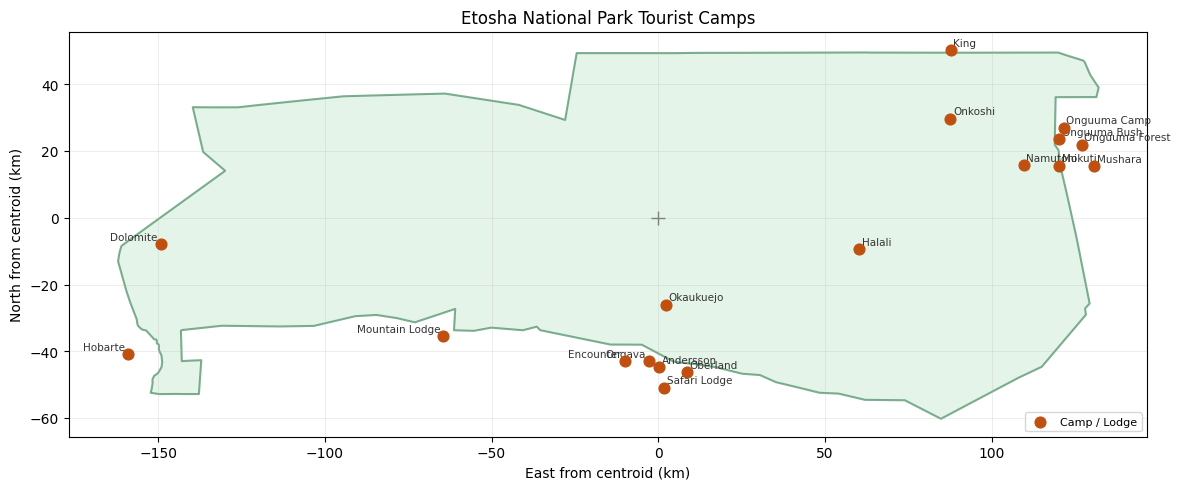

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from matplotlib.patches import Patch

# --- Camp data ---
camps = {
    "Mountain Lodge": (-19.264679, 15.283737),
    "Okaukuejo":      (-19.179762, 15.919016),
    "Oberland":       (-19.361732, 15.979226),
    "Safari Lodge":   (-19.403154, 15.913794),
    "Andersson":      (-19.347703, 15.900527),
    "Ongava":         (-19.331306, 15.870724),
    "Encounter":      (-19.332709, 15.802022),
    "Halali":         (-19.030026, 16.471228),
    "Namutoni":       (-18.803645, 16.939900),
    "Mokuti":         (-18.805075, 17.041246),
    "Mushara":        (-18.805941, 17.141283),
    "Onguuma Forest": (-18.747597, 17.105299),
    "Onguuma Bush":   (-18.733196, 17.041243),
    "Onguuma Camp":   (-18.701856, 17.053424),
    "Onkoshi":        (-18.677843, 16.731014),
    "King":           (-18.492639, 16.731432),
    "Dolomite":       (-19.016901, 14.478901),
    "Hobarte":        (-19.312357, 14.385638),
}

# --- Convert lat/lon to km from centroid ---
R = 6371.0

lats = np.array([v[0] for v in camps.values()])
lons = np.array([v[1] for v in camps.values()])
clat = -18.9454
clon = 15.8980


def to_km(lat, lon, clat, clon):
    x = np.radians(lon - clon) * R * np.cos(np.radians(clat))
    y = np.radians(lat - clat) * R
    return x, y

xs, ys = zip(*[to_km(lat, lon, clat, clon) for lat, lon in camps.values()])
names = list(camps.keys())

# --- Load and reproject shapefile ---
gdf = gpd.read_file("WDPA_WDOECM_Apr2026_Public_884_shp-polygons.shp")  # update path as needed
gdf = gdf.set_crs(epsg=4326)               # ensure WGS84

def transform_geometry(geom, clat, clon):
    """Convert shapefile geometry coordinates to km offsets from centroid."""
    from shapely.ops import transform
    def proj(lon, lat):
        x = np.radians(lon - clon) * R * np.cos(np.radians(clat))
        y = np.radians(lat - clat) * R
        return x, y
    return transform(proj, geom)

gdf_km = gdf.copy()
gdf_km["geometry"] = gdf_km["geometry"].apply(lambda g: transform_geometry(g, clat, clon))

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))

gdf_km.plot(ax=ax, facecolor="#d4edda", edgecolor="#2a7a4a", linewidth=1.5,
            linestyle="-", alpha=0.6, label="Etosha NP")

ax.scatter(xs, ys, color="#c05010", s=60, zorder=5, label="Camp / Lodge")

# Label each camp
for name, x, y in zip(names, xs, ys):
    ha = "left" if x >= 0 else "right"
    offset_x = 2 if x >= 0 else -2
    ax.annotate(name, (x, y), xytext=(offset_x, 3),
                textcoords="offset points", fontsize=7.5,
                ha=ha, color="#333333")

# Centroid marker
ax.plot(0, 0, marker="+", color="gray", markersize=10, zorder=4)


ax.set_xlabel("East from centroid (km)")
ax.set_ylabel("North from centroid (km)")
ax.set_title("Etosha National Park Tourist Camps")
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("etosha_camps.png", dpi=150)
plt.show()
